In [79]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [80]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
import sklearn.metrics as metrics
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST


In [81]:
BATCH_SIZE = 32
device = 'cpu'
transform = transforms.Compose([
    transforms.ToTensor()])
train_data = torchvision.datasets.MNIST(root='data', train=True, download=True, transform=transform,target_transform=None)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,num_workers=0)
test_data = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform,target_transform=None)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,num_workers=0)


In [82]:
train_data.data.shape, test_data.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

In [83]:
train_loader.dataset.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [84]:
len(train_data[10])

2

In [85]:
import torch
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
from torch_geometric.nn import GCNConv

In [86]:
dataset = KarateClub()
data = dataset[0].to(device)
data
dataset.num_features,dataset.num_classes

(34, 4)

In [87]:
type(dataset),data.edge_index.shape

(torch_geometric.datasets.karate.KarateClub, torch.Size([2, 156]))

In [88]:
import pandas as pd
# Convert node features to a pandas DataFrame
node_features_df = pd.DataFrame(data.x.numpy(), columns=[f'feature_{i}' for i in range(data.x.shape[1])])
node_features_df['node'] = node_features_df.index
node_features_df.set_index('node', inplace=True)

# Convert edge indices to a pandas DataFrame
edge_index_df = pd.DataFrame(data.edge_index.numpy().T, columns=['source', 'target'])

# Convert labels to a pandas DataFrame
labels_df = pd.DataFrame(data.y.numpy(), columns=['label'])
labels_df['node'] = labels_df.index
labels_df.set_index('node', inplace=True)

In [89]:
print(node_features_df)


      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   
5           0.0        0.0        0.0        0.0        0.0        1.0   
6           0.0        0.0        0.0        0.0        0.0        0.0   
7           0.0        0.0        0.0        0.0        0.0        0.0   
8           0.0        0.0        0.0        0.0        0.0        0.0   
9           0.0        0.0        0.0        0.0        0.0        0.0   
10          0.0        0.0        0.0        0.0        0.0        0.0   
11          0.0        0.0        0.0 

In [90]:
# Print node features DataFrame
print(f"\nNode features (shape: {node_features_df.shape}):")
print(node_features_df.head())  # Print only the first few rows for brevity


Node features (shape: (34, 34)):
      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
node                                                                     
0           1.0        0.0        0.0        0.0        0.0        0.0   
1           0.0        1.0        0.0        0.0        0.0        0.0   
2           0.0        0.0        1.0        0.0        0.0        0.0   
3           0.0        0.0        0.0        1.0        0.0        0.0   
4           0.0        0.0        0.0        0.0        1.0        0.0   

      feature_6  feature_7  feature_8  feature_9  ...  feature_24  feature_25  \
node                                              ...                           
0           0.0        0.0        0.0        0.0  ...         0.0         0.0   
1           0.0        0.0        0.0        0.0  ...         0.0         0.0   
2           0.0        0.0        0.0        0.0  ...         0.0         0.0   
3           0.0        0.0        0.0     

In [91]:

print(f"\nEdge indices (shape: {edge_index_df.shape}):")
print(edge_index_df)  


Edge indices (shape: (156, 2)):
     source  target
0         0       1
1         0       2
2         0       3
3         0       4
4         0       5
..      ...     ...
151      33      28
152      33      29
153      33      30
154      33      31
155      33      32

[156 rows x 2 columns]


In [92]:
num_countries = 4
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries, data.num_nodes))
data.y = countries
print(data.y)

tensor([2, 3, 0, 2, 2, 3, 0, 0, 2, 1, 2, 2, 2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3,
        3, 1, 1, 1, 3, 3, 0, 0, 3, 1])


In [93]:
data.x.shape, data.edge_index.shape, data.y.shape

(torch.Size([34, 34]), torch.Size([2, 156]), torch.Size([34]))

In [94]:
data.x,data.y

(tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]),
 tensor([2, 3, 0, 2, 2, 3, 0, 0, 2, 1, 2, 2, 2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 1, 3,
         3, 1, 1, 1, 3, 3, 0, 0, 3, 1]))

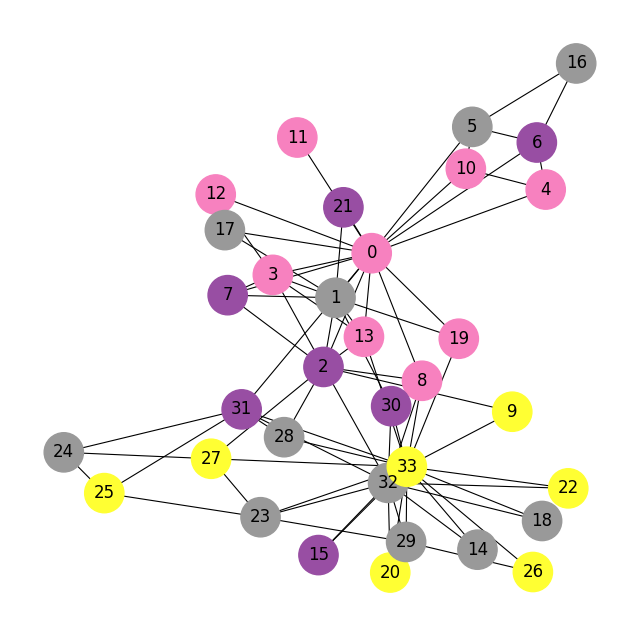

In [95]:
g = to_networkx(data, to_undirected=True)
plt.figure(figsize=(8,8))
plt.axis('off')
nx.draw_networkx(g, pos=nx.spring_layout(g,seed=0),node_size=800,vmin=-2,vmax=3,width=0.8,edge_color='black', with_labels=True, node_color=data.y, cmap='Set1')


In [96]:
from torch.nn import Module

In [97]:
class GCN(Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.middle = Linear(16,16)
        self.relu = nn.ReLU()
        self.conv2 = Linear(16, dataset.num_classes)
    def forward(self,x,edge_index):
        h = self.conv1(x, edge_index).relu()
        h = self.middle(h)
        z = self.conv2(h)
        return h,z
model0 = GCN().to(device)
print(model0)

GCN(
  (conv1): GCNConv(34, 16)
  (middle): Linear(in_features=16, out_features=16, bias=True)
  (relu): ReLU()
  (conv2): Linear(in_features=16, out_features=4, bias=True)
)


In [98]:
unique_params = sum(dict((p.data_ptr(), p.numel()) for p in model0.parameters()).values())
unique_params

900

In [99]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model0.parameters(), lr=0.01)


In [100]:
def accuracy(pred_y,y):
    pred_labels = pred_y.argmax(dim=1)
    correct = (pred_labels == y).sum().item()
    total = y.size(0)
    return correct / total

In [101]:
embeddings = []
losses = []
accuracies = []
outputs = []

EPOCHS = 200
for epoch in range(EPOCHS):
    model0.train()
    optimizer.zero_grad()
    h,z = model0(data.x, data.edge_index)
    epoch_loss = criterion(z, data.y)
    acc = accuracy(z, data.y)
    epoch_loss.backward()
    optimizer.step()
    
    embeddings.append(h.detach().numpy())
    losses.append(epoch_loss.item())
    accuracies.append(acc)
    outputs.append(z.detach().numpy())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss.item():.4f}, Accuracy: {acc:.4f}")

Epoch 0, Loss: 1.3934, Accuracy: 0.2059
Epoch 20, Loss: 0.9776, Accuracy: 0.5294
Epoch 40, Loss: 0.3921, Accuracy: 0.8529
Epoch 60, Loss: 0.0921, Accuracy: 0.9706
Epoch 80, Loss: 0.0139, Accuracy: 1.0000
Epoch 100, Loss: 0.0045, Accuracy: 1.0000
Epoch 120, Loss: 0.0025, Accuracy: 1.0000
Epoch 140, Loss: 0.0018, Accuracy: 1.0000
Epoch 160, Loss: 0.0013, Accuracy: 1.0000
Epoch 180, Loss: 0.0011, Accuracy: 1.0000
